In this project, we will develop a system to detect and recognize sign language letters using advanced computer vision and machine learning techniques. The aim is to create a reliable tool that can interpret hand gestures representing the alphabet, aiding communication for the deaf and hard-of-hearing community.

We will use a publicly available dataset from Kaggle (https://www.kaggle.com/datasets/grassknoted/asl-alphabet) that contains a comprehensive set of images depicting various sign language letters. Our approach will involve preprocessing the images, training multiple neural networks to recognize these gestures, and evaluating the models' accuracy in identifying the correct letter from a set of input images.

By the end of the project, we expect to have a functional sign language detection model capable of recognizing a broad range of sign language letters with high accuracy. This work could be further expanded to detect sign language words or even entire sentences, contributing to improved communication and accessibility for those who use sign language as their primary means of communication.


Note:
Due to the large size of the original dataset, which is originally located in the data/external folder, we have not included it in our project submission. However, we have included the final preprocessed data files in the following locations:
data/divided/images_dataset.npz and
data/divided/landmarks_dataset.npz
These preprocessed files contain all the necessary data for reproducing our results.


### 1) Importing necessary dependencies

In [1]:
import cv2
import joblib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

### 2) Loading images into a dictionary

This script organizes image paths into a Python dictionary to facilitate structured access to a large dataset of American Sign Language (ASL) letter images. It iterates through a specified folder containing subfolders for each ASL letter, collecting up to 500 valid image paths per letter. The result is a dictionary where keys represent ASL letters and values are lists of corresponding image paths, enabling easy retrieval for further processing.

In [2]:
import os

# Path to the folder containing images
images_folder_path = "../../dataset"

# Dictionary that will contain letters as keys, with an array of image paths as value
letters_images = {}

for letter in os.listdir(images_folder_path):
    # Store images for each letter
    images = []
    letter_path = os.path.join(images_folder_path, letter)
    # Skipping if letter_path is not a folder , or if it does not represent a character (has a length > 1)
    if not os.path.isdir(letter_path) or len(letter) > 1:
        # Skip this iteration if letter_path is not a dir
        continue
    
    images_count = 0
    # Iterating through each image inside the letter folder
    for image_file in os.listdir(letter_path):
        if not image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue  # Skip if not an image file
        
        # Break the loop if we've collected 500 images
        if images_count == 500:
            break
        
        # Finding the path for the image
        image_path = os.path.join(letter_path, image_file)
        # Storing image path in the array
        images.append(image_path)
        images_count += 1
    
    # Store the list of images for the current letter in the dictionary
    letters_images[letter] = images

# Now letters_images dictionary contains lists of up to 500 images for each letter
# You can access images for a specific letter like letters_images['A']


### 3) Reading images using OpenCV

This code snippet reads image files from a dictionary where keys represent letters and values are lists of corresponding image paths. It processes each image, converting it from BGR to RGB format, and stores the processed images in a list X, while their corresponding letter labels are stored in y

In [3]:
X = []
y = []

# Transforming data from a dictionary to a tuple for destructuring
letters_images_tuple = letters_images.items()

for letter, image_paths in letters_images_tuple:
    for image_path in image_paths:
        # Read image file using openCV
        image_bgr = cv2.imread(image_path)
        # Check if the image was successfully loaded
        if image_bgr is not None:
            # Converting image from BGR to RGB 
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            X.append(image_rgb)
            y.append(letter)
        else:
            print(f"Warning: Failed to load image '{image_path}'")
        
X[:5]

[array([[[  0,   0, 252],
         [  4,   3, 255],
         [  0,   0, 245],
         ...,
         [  6,   0, 250],
         [  0,   2, 247],
         [  0,   4, 247]],
 
        [[  4,   3, 254],
         [  0,   0, 231],
         [ 12,  11, 213],
         ...,
         [ 15,   8, 199],
         [  1,   3, 210],
         [  0,   7, 220]],
 
        [[  1,   0, 241],
         [  7,   6, 204],
         [ 97,  97, 209],
         ...,
         [197, 191, 255],
         [205, 204, 255],
         [ 10,  13, 170]],
 
        ...,
 
        [[  7,   3, 250],
         [  3,   2, 192],
         [ 91,  94, 173],
         ...,
         [153, 151, 165],
         [146, 147, 237],
         [ 10,  14, 139]],
 
        [[  1,   2, 250],
         [  6,   8, 217],
         [ 76,  79, 212],
         ...,
         [143, 144, 234],
         [133, 140, 255],
         [  5,  14, 167]],
 
        [[  0,   1, 248],
         [  1,   4, 223],
         [ 12,  14, 176],
         ...,
         [ 14,  18, 143],
  

Transforming X and y variables into numpy arrays to examine their shape

In [4]:
X = np.array(X)
y = np.array(y)

In [5]:
X.shape

(13000, 200, 200, 3)

In [6]:
y.shape

(13000,)

### 3) Data Exploration

In [7]:
def visualize_images(X, y):
    num_images_to_visualize = 5
    fig, axes = plt.subplots(1, num_images_to_visualize, figsize=(12, 3))

    for i in range(num_images_to_visualize):
        # Randomly select an index
        idx = np.random.randint(0, len(X))
        img = X[idx]
        label = y[idx]
        
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Letter: {label}")
        axes[i].axis('off')

    plt.show()

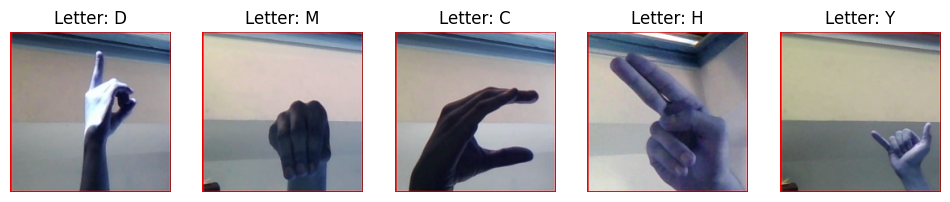

In [8]:
visualize_images(X, y)

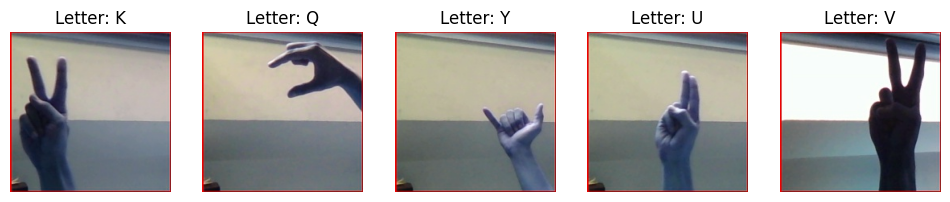

In [9]:
visualize_images(X, y)

In [10]:
# Create a table using pandas to count the occurrences of each letter
def show_y_table(y):
    letter_counts = pd.Series(y).value_counts().reset_index()
    letter_counts.columns = ['Letter', 'Count']
    letter_counts = letter_counts.sort_values(by='Letter')
    return letter_counts

In [11]:
y_train_counts = show_y_table(y)
y_train_counts

,Letter,Count
8,A,500
20,B,500
14,C,500
15,D,500
19,E,500
9,F,500
4,G,500
11,H,500
2,I,500
13,J,500



The dataset now includes 18,000 images, with 3,000 images for each letter.

### 5) Saving images data for persistance

In [12]:
joblib.dump(X, '../../data/raw/X.joblib')
joblib.dump(y, '../../data/raw/y.joblib')

['../../data/raw/y.joblib']